In [ ]:
# Student Lifestyle and Academic Performance Analysis

This project explores how lifestyle factors such as study hours, sleep duration, and social media usage affect students' academic performance and mental health.

The dataset contains information on student habits including study time, sleep, physical activity, stress level, and CGPA. The goal is to explore relationships between these variables using visualization and statistical modelling. Shift + Enter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm 
  

Matplotlib is building the font cache; this may take a moment.


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [8]:
df = pd.read_csv("student_lifestyle_100k.csv")
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114.0,5.0,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142.0,2.0,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137.0,3.0,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130.0,3.0,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4.0,6.0,False


In [9]:
df.shape

(20539, 11)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20539 entries, 0 to 20538
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          20539 non-null  int64  
 1   Age                 20539 non-null  int64  
 2   Gender              20539 non-null  str    
 3   Department          20539 non-null  str    
 4   CGPA                20538 non-null  float64
 5   Sleep_Duration      20538 non-null  float64
 6   Study_Hours         20538 non-null  float64
 7   Social_Media_Hours  20538 non-null  float64
 8   Physical_Activity   20538 non-null  float64
 9   Stress_Level        20538 non-null  float64
 10  Depression          20538 non-null  object 
dtypes: float64(6), int64(2), object(1), str(2)
memory usage: 1.7+ MB


In [11]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,20539.000000,20539.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000,20538.000000
mean,11270.000000,21.014217,2.902706,6.987068,4.518887,3.509748,74.518697,4.137404
std,5929.242925,2.006148,0.533852,1.500963,1.971813,1.488135,43.261576,1.418927
min,1001.000000,18.000000,1.590000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,6135.500000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,11270.000000,21.000000,2.910000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,16404.500000,23.000000,3.357500,8.000000,5.900000,4.500000,112.000000,5.000000
max,21539.000000,24.000000,4.000000,12.000000,12.300000,9.800000,149.000000,10.000000


In [12]:
df.corr(numeric_only=True)

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
Student_ID,1.000000,-0.008406,-0.008894,-0.001501,-0.000898,-0.009030,-0.003154,-0.001605
Age,-0.008406,1.000000,0.001844,0.001934,-0.000493,-0.007469,-0.006848,0.003981
CGPA,-0.008894,0.001844,1.000000,0.013124,0.099148,-0.097222,0.010509,-0.025821
Sleep_Duration,-0.001501,0.001934,0.013124,1.000000,0.009904,-0.000664,0.006385,-0.284583
Study_Hours,-0.000898,-0.000493,0.099148,0.009904,1.000000,0.006256,0.000452,-0.000010
Social_Media_Hours,-0.009030,-0.007469,-0.097222,-0.000664,0.006256,1.000000,0.005647,0.004713
Physical_Activity,-0.003154,-0.006848,0.010509,0.006385,0.000452,0.005647,1.000000,-0.295620
Stress_Level,-0.001605,0.003981,-0.025821,-0.284583,-0.000010,0.004713,-0.295620,1.000000


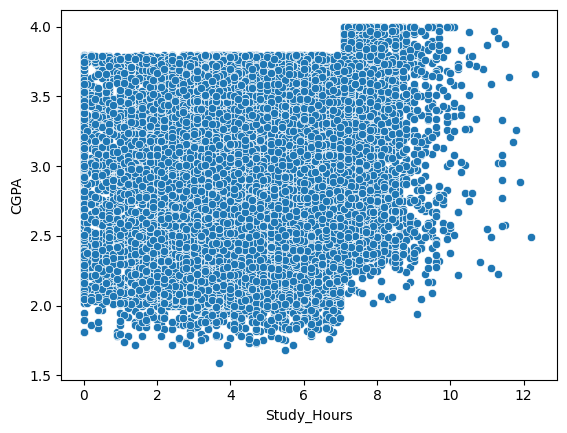

In [13]:
sns.scatterplot(x="Study_Hours", y="CGPA", data=df)
plt.show()

In [15]:
df = df.dropna()

In [16]:
X = df[["Study_Hours", "Sleep_Duration", "Social_Media_Hours", "Stress_Level", "Physical_Activity"]]
y = df["CGPA"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   CGPA   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     84.19
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           7.41e-88
Time:                        16:21:12   Log-Likelihood:                -16043.
No. Observations:               20538   AIC:                         3.210e+04
Df Residuals:                   20532   BIC:                         3.215e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.9208      0

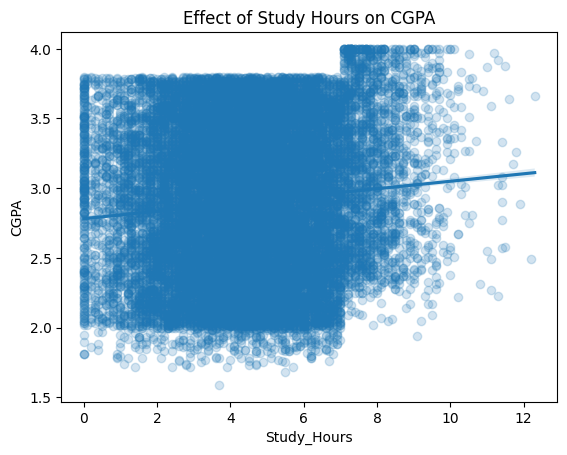

In [17]:
sns.regplot(x="Study_Hours", y="CGPA", data=df, scatter_kws={"alpha":0.2})
plt.title("Effect of Study Hours on CGPA")
plt.show()